# Employee Attrition Prediction Model

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Task 1 (Data Loading & Exploration)

In [2]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [3]:
print(df.shape)

(1470, 35)


In [4]:
df['Attrition'].head()

0    Yes
1     No
2    Yes
3     No
4     No
Name: Attrition, dtype: object

In [5]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [6]:
attrition_rate = (
    df['Attrition'].value_counts()['Yes']
    / len(df)
) * 100

print(attrition_rate)

16.122448979591837


In [7]:
numerical_cols = df.select_dtypes(include=['int64','float64']).columns

categorical_cols = df.select_dtypes(include=['object']).columns

print("Numerical:", len(numerical_cols))
print("Categorical:", len(categorical_cols))

Numerical: 26
Categorical: 9


### My Observation
 
Only around 16% of employees have left the company while 84% stayed. This indicates an imbalanced dataset because the number of employees who stayed is much larger than the number who left.

## Task 2 (Data Cleaning)

In [8]:
# Check for null values
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [9]:
# Drop useless columns
df.drop(
    ['EmployeeNumber',
     'Over18',
     'StandardHours',
     'EmployeeCount'],
    axis=1,
    inplace=True
)

In [10]:
# Encodeing the columns
df['Attrition'] = df['Attrition'].map({
    'Yes':1,
    'No':0
})

In [11]:
X = df.drop('Attrition', axis=1)

y = df['Attrition']

In [12]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [13]:
# Scale numeric features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Task 3 (EDA)

In [14]:
dept_attrition = pd.crosstab(
    df['Department'],
    df['Attrition'],
    normalize='index'
)*100

dept_attrition

Attrition,0,1
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


Sales department loses the most employees

In [15]:
role_attrition = pd.crosstab(
    df['JobRole'],
    df['Attrition'],
    normalize='index'
)*100
role_attrition

Attrition,0,1
JobRole,,
Healthcare Representative,93.129771,6.870229
Human Resources,76.923077,23.076923
Laboratory Technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing Director,93.103448,6.896552
Research Director,97.500000,2.500000
Research Scientist,83.904110,16.095890
Sales Executive,82.515337,17.484663
Sales Representative,60.240964,39.759036


Sales representative job role has the highest attrition rate

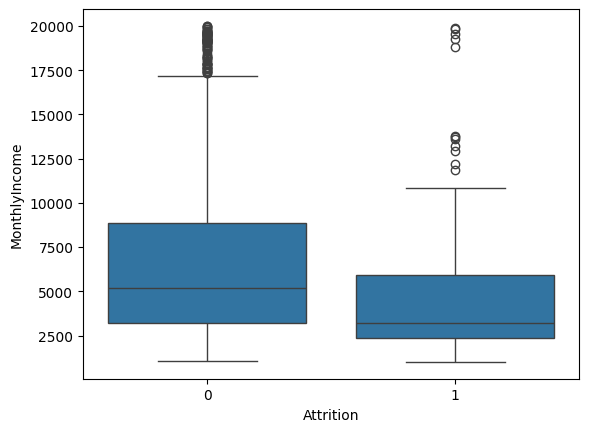

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df
)
plt.savefig("charts/monthly_income_attrition.png")
plt.show()

Lower-paid employees leave significantly more. The ₹2–4k group are experienced enough to have options but not paid enough to stay

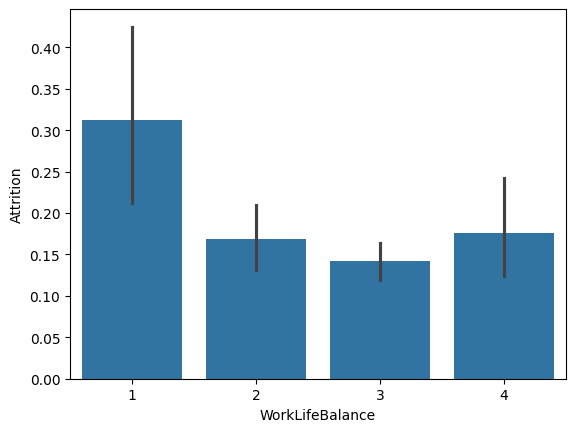

In [42]:
sns.barplot(
    x='WorkLifeBalance',
    y='Attrition',
    data=df
)
plt.savefig("charts/attrition_distribution.png",
            bbox_inches='tight',
            dpi=300)

plt.show()

Poor work-life balance nearly triples attrition risk. The biggest jump is between rating 1 and rating 2 (39% → 24%). 

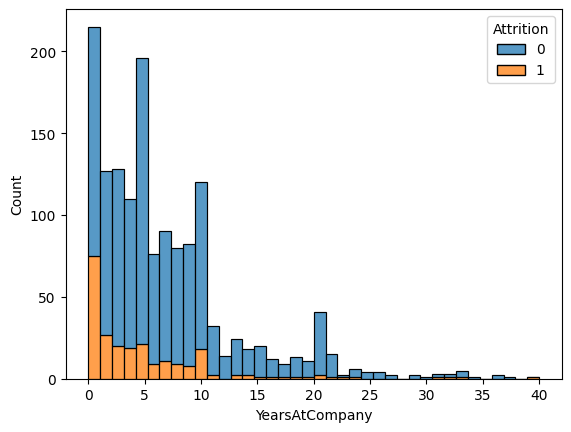

In [43]:
sns.histplot(
    data=df,
    x='YearsAtCompany',
    hue='Attrition',
    multiple='stack'
)
plt.savefig("charts/years_at_company.png")
plt.show()

The first year is where the most people leave the company. Nearly all attrition risk is concentrated in the first 3 years of employment.

### Specific business insights 
Sales Representatives are the highest-risk job role. With an attrition rate of ~40%, Sales Reps leave at more than double the company average. Combined with the Sales department's overall attrition rate of ~21% (also the highest department), Sales is the single highest-priority area for retention investment. One in three Sales Reps will leave in any given period.

Income gap alone doesn't fully explain attrition — overtime and travel amplify it. The median income of employees who left is about 30% lower than those who stayed (₹4,787 vs ₹6,833). However, employees with poor WLB who also earn under ₹4k face compounding risk factors. The data suggests that low pay combined with high overtime and frequent business travel creates the highest-risk employee profile — not any single factor alone.

Laboratory Technicians showed an attrition rate of 23.9%, indicating elevated turnover in technical operational roles.
Employees who left earned an average monthly income of ₹4,787 compared to ₹6,833 for employees who stayed, suggesting compensation may contribute to turnover.
Overtime emerged as one of the strongest indicators of attrition, suggesting workload and work-life balance are major retention concerns.

## Task 4 (Model Building and Comparison)

In [20]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
# Training Logistic regression model
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

lr.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [22]:
# Training Random Forest regressor model
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [23]:
# Training Gradient Boosting Classifier model
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train,y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

## Task 5 (Model Evaluation)

In [24]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

In [25]:
# Evaluating the 3 models performance
results = []

for name, model in [
    ("Logistic Regression", lr),
    ("Random Forest", rf),
    ("Gradient Boosting", gb)
]:

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:,1]

    results.append({
        "Model": name,
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, prob)
    })

comparison = pd.DataFrame(results)

comparison

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.341176,0.617021,0.439394,0.798605
1,Random Forest,0.375000,0.063830,0.109091,0.751917
2,Gradient Boosting,0.588235,0.212766,0.312500,0.794125


## Findings
Logistic Regression achieved the highest Recall (61.7%), F1 Score (43.9%), and ROC-AUC (79.9%), making it the most effective model overall. Since employee attrition prediction prioritizes identifying employees at risk of leaving, Logistic Regression was selected as the final model. Gradient Boosting achieved the highest Precision (58.8%) but missed a substantial number of attrition cases. Random Forest showed the weakest performance, particularly in Recall (6.4%), indicating poor detection of employees likely to leave.

In [26]:
print(type(X))
print(type(X_train))
X.columns

<class 'pandas.core.frame.DataFrame'>
<class 'numpy.ndarray'>


Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely',
       'Department_Research & Development', 'Department_Sales',
       'EducationField_Life Sciences', 'EducationField_Marketing',
       'EducationField_Medical', 'EducationField_Other',
       'EducationField_Technical Degree', 'Gender_Male',
       'JobRole_Human Resources', 'JobRole_Laboratory Technician',
       'JobRole_Manager', 'JobRole_Manufacturing Director',
       'JobRole_Research Director', 'JobRole_Research Scienti

In [27]:
print(len(X.columns))
print(len(lr.coef_[0]))

44
44


In [28]:
# Feature importance - Logistic regression
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
})

feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()


In [29]:
feature_importance

,Feature,Coefficient,Abs_Coefficient
0,Age,-0.267331,0.267331
1,DailyRate,-0.232780,0.232780
2,DistanceFromHome,0.322178,0.322178
3,Education,0.020215,0.020215
4,EnvironmentSatisfaction,-0.435730,0.435730
5,HourlyRate,-0.055970,0.055970
6,JobInvolvement,-0.288050,0.288050
7,JobLevel,0.659189,0.659189
8,JobSatisfaction,-0.390850,0.390850
9,MonthlyIncome,-0.100379,0.100379


In [30]:
# Top 10 most important features
feature_importance = pd.Series(
    abs(lr.coef_[0]),
    index=X.columns
)

print(feature_importance.sort_values(ascending=False).head(10))

JobRole_Laboratory Technician       0.797874
OverTime_Yes                        0.766412
BusinessTravel_Travel_Frequently    0.719335
JobLevel                            0.659189
TotalWorkingYears                   0.656931
JobRole_Sales Representative        0.552515
BusinessTravel_Travel_Rarely        0.511649
EducationField_Life Sciences        0.506505
YearsSinceLastPromotion             0.500389
Department_Sales                    0.481690
dtype: float64


## Task 6 (Visualization)

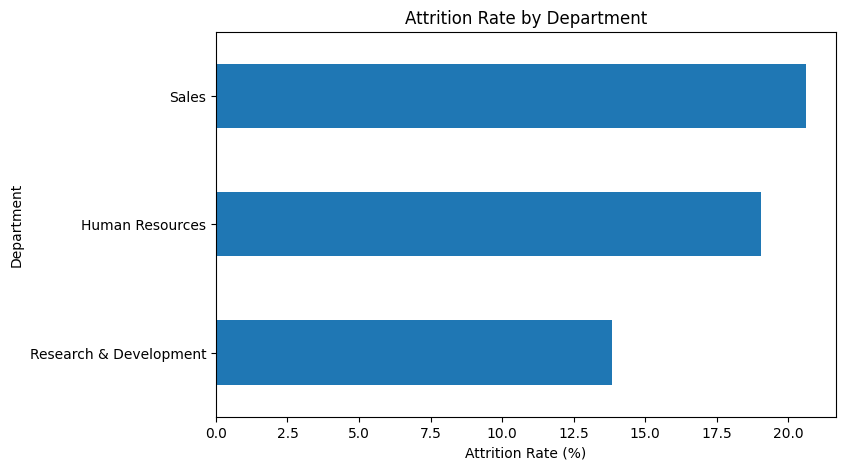

In [44]:
# Attrition rate by department
dept_attrition[1].sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title('Attrition Rate by Department')
plt.xlabel('Attrition Rate (%)')
plt.savefig("charts/department_attrition.png")
plt.show()

In [32]:
print(dept_attrition)

Attrition                       0          1
Department                                  
Human Resources         80.952381  19.047619
Research & Development  86.160250  13.839750
Sales                   79.372197  20.627803


In [33]:
# Attrition rate by jobrole
jobrole_attrition = pd.crosstab(
    df['JobRole'],
    df['Attrition'],
    normalize='index'
) * 100

In [34]:
print(jobrole_attrition)

Attrition                          0          1
JobRole                                        
Healthcare Representative  93.129771   6.870229
Human Resources            76.923077  23.076923
Laboratory Technician      76.061776  23.938224
Manager                    95.098039   4.901961
Manufacturing Director     93.103448   6.896552
Research Director          97.500000   2.500000
Research Scientist         83.904110  16.095890
Sales Executive            82.515337  17.484663
Sales Representative       60.240964  39.759036


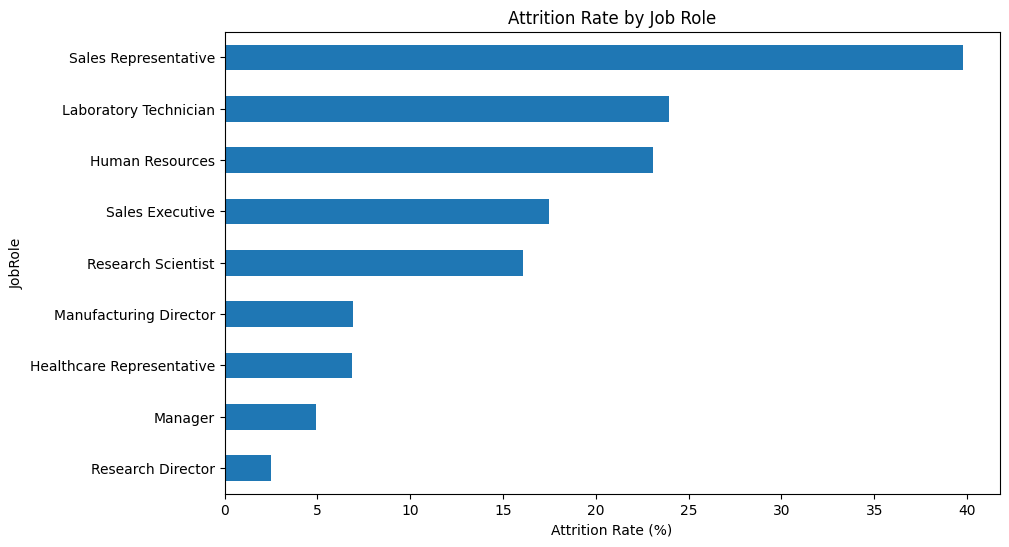

In [45]:
jobrole_attrition[1].sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Attrition Rate by Job Role')
plt.xlabel('Attrition Rate (%)')
plt.savefig("charts/jobrole_attrition.png")
plt.show()

<Axes: xlabel='Attrition', ylabel='MonthlyIncome'>

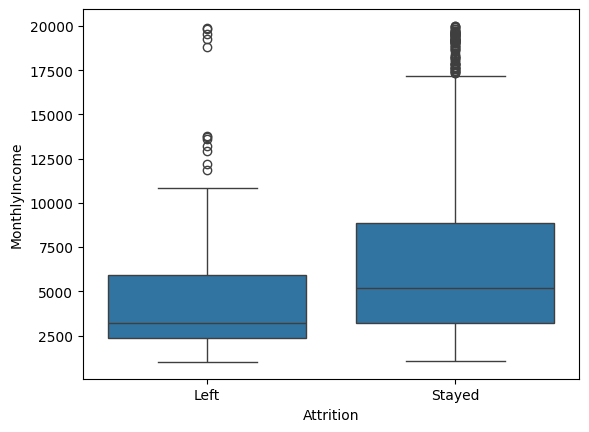

In [47]:
# Monthly income of employees : left vs stayed
sns.boxplot(
    x=df['Attrition'].map({0:'Stayed',1:'Left'}),
    y=df['MonthlyIncome']
)

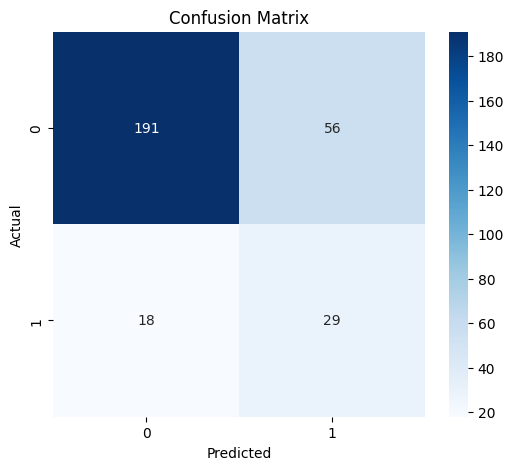

In [48]:
# Confusion matrix for logistic regression model
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = lr.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig("charts/confusion_matrix.png")
plt.show()

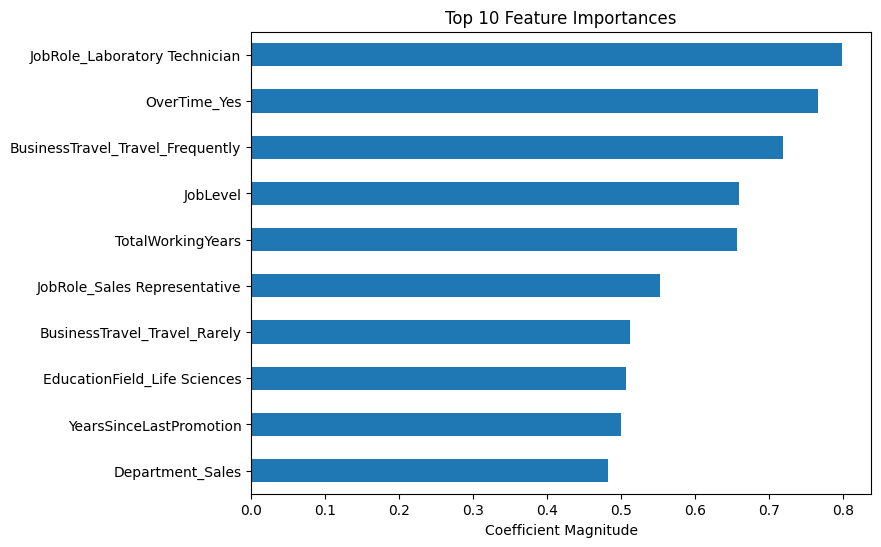

In [50]:
# Top 10 Feature Importances
feature_importance = pd.Series(
    abs(lr.coef_[0]),
    index=X.columns
)

top10 = feature_importance.sort_values(
    ascending=False
).head(10)

top10.sort_values().plot(
    kind='barh',
    figsize=(8,6)
)

plt.title('Top 10 Feature Importances')
plt.xlabel('Coefficient Magnitude')
plt.savefig("charts/top_10_feature_importances.png")
plt.show()

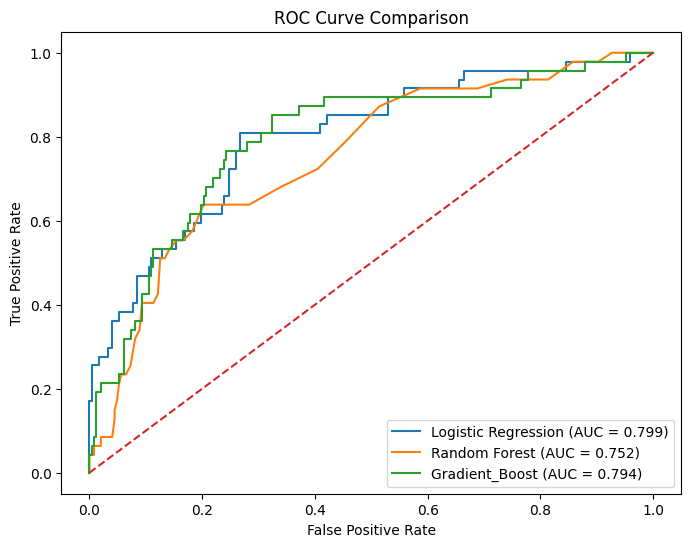

In [49]:
# ROC Curve comparing the 3 models
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

models = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'Gradient_Boost': gb
}

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'{name} (AUC = {roc_auc:.3f})'
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.savefig("charts/roc_curve_comparison.png")
plt.show()

In [40]:
# Attrition by Monthly income statistics 
df.groupby('Attrition')['MonthlyIncome'].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
0,1233.0,6832.739659,4818.208001,1051.0,3211.0,5204.0,8834.0,19999.0
1,237.0,4787.092827,3640.210367,1009.0,2373.0,3202.0,5916.0,19859.0


## Task 7 (Insights and Business Recommendations)

The Logistic Regression model performed best with a ROC-AUC score of 0.799 and was therefore used for interpretation. 
The strongest predictors of employee attrition were being a Laboratory Technician, working overtime, and frequent business travel. 
Employees in the Sales department showed the highest department-level attrition rate (20.63%), while Sales Representatives had the highest attrition among all job roles (39.76%), making them the highest-priority group for retention efforts. Although employees who left had a lower average monthly income than those who stayed, salary alone does not explain attrition. Factors such as overtime, job role, travel frequency, job level, and promotion history appear to have a stronger influence. 

Our analysis shows that employees who work frequent overtime, travel regularly for work, and work in certain roles are more likely to leave the company. In particular, Sales Representatives and Laboratory Technicians show higher levels of employee turnover compared to other job roles. The Sales department has the highest overall attrition rate, making it a key area for retention efforts.

While employees who left the company generally earned less on average than those who stayed, salary does not appear to be the only or most important reason for attrition. Workload, travel demands, career growth opportunities, and job role characteristics appear to have a stronger influence on an employee's decision to leave.

To reduce attrition, HR should prioritize retention conversations with employees in Sales Representative and Laboratory Technician roles, especially those who frequently work overtime or travel often. The company should also review workload expectations and provide clearer career development and promotion opportunities for employees in high-risk groups.

One limitation of this analysis is that it identifies patterns associated with employees leaving but cannot determine the exact reason why an individual employee decides to leave. Therefore, these findings should be used alongside employee feedback, surveys, and manager insights when making HR decisions.
